In [82]:
import sys
import os

# detect the environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# configure the paths
if IN_COLAB:
    print("Running in Google Colab. Setting up GitHub repo...")
    REPO_URL = "https://github.com/JayC-SF/COMP-432-Project.git"
    REPO_DIR = "/content/COMP-432-Project"

    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}

    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
    
    !pip install optuna
    
    # change the working directory
    os.chdir(REPO_DIR)
else:
    print("Running locally. Setting up relative paths...")
    # move up only if base directory is at notebooks
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
        print(f"Working directory changed to: {os.getcwd()}")

    # add working dir to sys path
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())

    %load_ext autoreload
    %autoreload 2

from src import preprocess_data as prepd
from src.models.NN import ClassicCNN
import src.variables as v
import numpy as np
import torch
from src.train.orchestrator import Orchestrator
from src.utils.hardware import get_device
from src.utils.seed import set_seed
from src.datasets import ICSD_MelSpectogram
from torch.utils.data import DataLoader
import copy
import gc
import optuna
import joblib
import src.utils.plotting as plotting
import pandas as pd
set_seed(v.SEED)

Running locally. Setting up relative paths...
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Seed set to: 42


Download the mel spectogram `.npz` dataset from a Google Drive ID And save it locally. If `.npz` file already exists the following cell skips the downloading process.

In [41]:
prepd.download_google_file(v.MEL_SPECTOGRAM_NPZ_FILE_PATH, v.MEL_SPECTOGRAM_NPZ_GID)

data/mel_spectogram_audio_length_adjusted.npz already exists.


In [42]:
data = np.load(v.MEL_SPECTOGRAM_NPZ_FILE_PATH)
train_ds = ICSD_MelSpectogram(data['X_train'], data['y_train'])
val_ds = ICSD_MelSpectogram(data['X_val'], data['y_val'])
test_ds = ICSD_MelSpectogram(data['X_test'], data['y_test'])

We load the dataset into their respective splits, If you need more workers you can change the number of workers two right to other values.

In [43]:
NUM_WORKERS = 0 # change if needed
set_seed(v.SEED)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

✅ Seed set to: 42


We create the following functions in order to help with the fine tuning set and as well training the baseline model. The `create_orchestrator` function creates an orchestrator for the training it can also be configured to include a custom learning rate and weight decay that is useful to fine tuning.

In [44]:
def create_orchestrator(name, lr, wd, trial=None):
    set_seed(v.SEED)
    
    # use output 2 classes so we can use standard multi class logic for training orchestrator
    LEARNING_RATE = lr
    WEIGHT_DECAY = wd
    PATIENCE = 15
    SAVE_PATH = v.RUNS_PATH/name
    MAX_EPOCHS = 500
    model = ClassicCNN(num_classes=2)
    DEVICE = get_device()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        weight_decay = WEIGHT_DECAY,
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=5,
        factor=0.1,
    )
    criterion = torch.nn.CrossEntropyLoss()

    orchestrator = Orchestrator(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        patience=PATIENCE,
        save_path=SAVE_PATH,
        scheduler=scheduler,
        max_epochs=MAX_EPOCHS,
        classes=v.CLASSES,
        trial=trial
    )

    return orchestrator
def train_model(name, lr, wd, trial=None):
    orchestrator = create_orchestrator(name, lr, wd, trial)
    print(f"\n🚀 Training {name} | LR: {lr} | WD: {wd}")
    if trial is None:
        print(f"📂 Saving to: {orchestrator.save_path}")

    orchestrator.train()
    return orchestrator

We train the baseline model here with the baseline learning rate and weight to decay.

In [ ]:
baseline_orchestrator = train_model(name="ClassicCNN_baseline", lr=1e-3, wd=5e-5)

✅ Seed set to: 42
🚀 Recovering state from disk...

🚀 Training ClassicCNN_baseline | LR: 0.001 | WD: 5e-05
📂 Saving to: runs\ClassicCNN_baseline
Running with device:cuda
---- Starting Epoch 21 ----


Train Loss: 0.0356 | Train Acc: 98.4858%


Val Loss: 0.1590 | Val Acc: 94.9168%
Saved checkpoint data under runs\ClassicCNN_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 4/15
---- Starting Epoch 22 ----


Train Loss: 0.0330 | Train Acc: 98.6405%


Val Loss: 0.1683 | Val Acc: 94.8244%
📉 Learning rate reduced to 1.00e-05
Saved checkpoint data under runs\ClassicCNN_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 5/15
---- Starting Epoch 23 ----


...

Val Loss: 0.1708 | Val Acc: 95.4713%
Saved checkpoint data under runs\ClassicCNN_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 13/15
---- Starting Epoch 31 ----


Train Loss: 0.0246 | Train Acc: 99.0313%


Val Loss: 0.1723 | Val Acc: 95.2865%
Saved checkpoint data under runs\ClassicCNN_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 14/15
---- Starting Epoch 32 ----


Train Loss: 0.0242 | Train Acc: 99.0068%


Val Loss: 0.1731 | Val Acc: 95.4713%
Saved checkpoint data under runs\ClassicCNN_baseline\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 15/15
🛑 Early stopping triggered.
Completed training at epoch 32


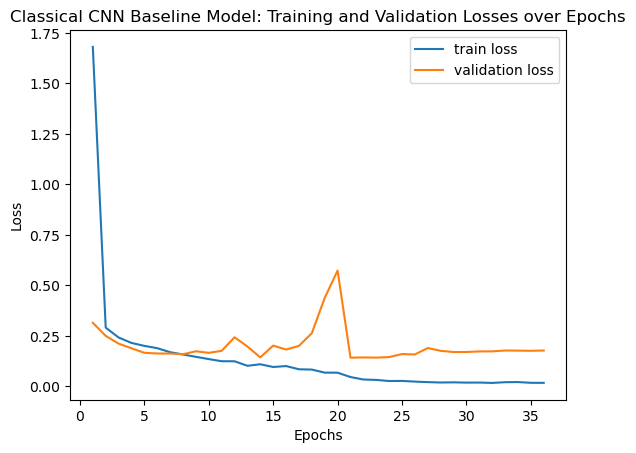

Best model's validation loss (0.14230672136472466) achieved at epoch 21
Best model's training loss (0.04641247166060481)
Total epochs (36)


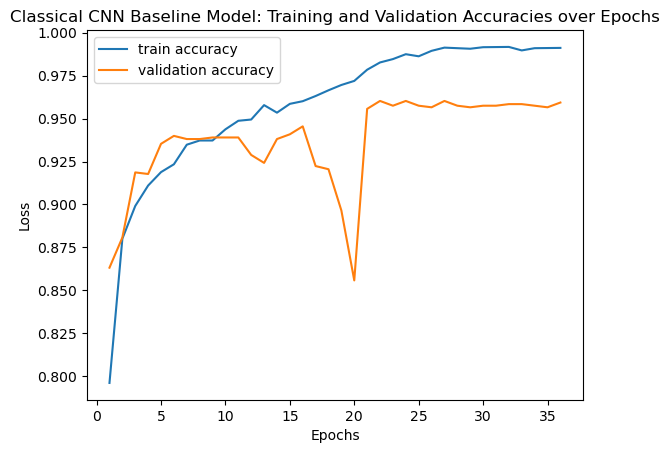

Best epoch's validation accuracy: 95.563771%
Best epoch's training accuracy: 97.842722%


In [88]:
plotting.plot_orchestrator_training_summary(baseline_orchestrator, "Classical CNN Baseline Model")

In [46]:
results = baseline_orchestrator.test(test_loader, baseline_orchestrator.th.best_model_weights)

Test Loss: 0.0810 | Test Acc: 97.0425%


              precision    recall  f1-score   support

     Snoring       0.95      0.99      0.97       539
   InfantCry       0.99      0.95      0.97       543

    accuracy                           0.97      1082
   macro avg       0.97      0.97      0.97      1082
weighted avg       0.97      0.97      0.97      1082



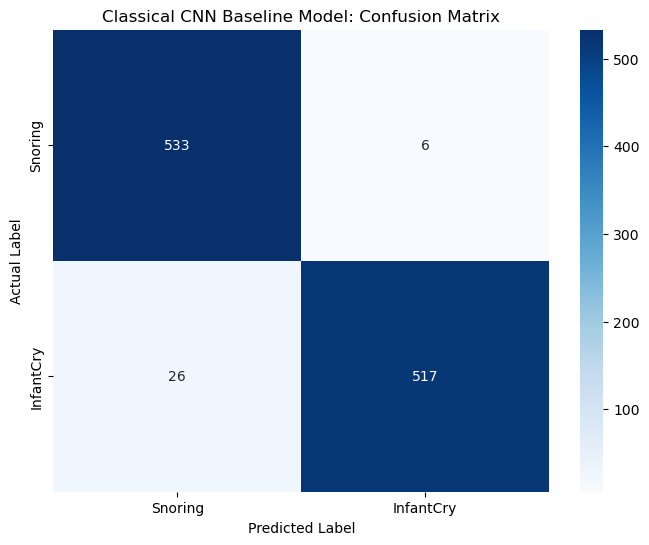

Test Loss: 0.0810 | Test Acc: 97.0425%


In [72]:
plotting.plot_test_results(results, "Classical CNN Baseline Model")

Perform hyperparameter search on learning weight and weight decay. The hyperparam is performed with 15 trials.

In [15]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    wd = trial.suggest_float("wd", 1e-6, 1e-1, log=True)
    
    orchestrator = train_model(name=f"ClassicCNN_trial_{trial.number}", lr=lr, wd=wd, trial=trial)
    
    best_val_loss = orchestrator.th.best_val_loss
    
    del orchestrator
    gc.collect() 
    torch.cuda.empty_cache()
    
    return best_val_loss

In [16]:
study = optuna.create_study(
    direction="minimize", 
    study_name="ClassicCNN_ICSD_Optimization"
)

study.optimize(objective, n_trials=15)

[I 2026-04-18 17:15:33,549] A new study created in memory with name: ClassicCNN_ICSD_Optimization


✅ Seed set to: 42

🚀 Training ClassicCNN_trial_0 | LR: 0.0006477032646008446 | WD: 7.142724368991471e-06
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 1.1502 | Train Acc: 80.4705%


Val Loss: 0.2836 | Val Acc: 88.9094%
🌟 New Best Model! Val Loss decreased from inf to 0.2836
---- Starting Epoch 2 ----


Train Loss: 0.2890 | Train Acc: 87.7157%


...

[I 2026-04-18 18:38:45,971] Trial 13 pruned.                          


Val Loss: 0.3287 | Val Acc: 88.5397%
✂️ Trial pruned at epoch 1
✅ Seed set to: 42

🚀 Training ClassicCNN_trial_14 | LR: 0.0013699043085749815 | WD: 3.0872708056874887e-06
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 2.1403 | Train Acc: 80.5194%


[I 2026-04-18 18:39:06,255] Trial 14 pruned.                          


Val Loss: 0.3008 | Val Acc: 87.4307%
✂️ Trial pruned at epoch 1


In [ ]:
optuna_fname = "ClassicCNN_ICSD_Optimization_Optuna_Study"
joblib.dump(study, v.RUNS_PATH/f"{optuna_fname}.pkl")
fine_tune_history_df = study.trials_dataframe()
fine_tune_history_df.to_csv(v.RUNS_PATH/f"{optuna_fname}.csv", index=False)

In [85]:
# to avoid re running things
fine_tune_history_df = pd.read_csv(v.RUNS_PATH/f"{optuna_fname}.csv")
fine_tune_history_df

,number,value,datetime_start,datetime_complete,duration,params_lr,params_wd,state
0,0,0.134810,2026-04-18 17:15:33.550356,2026-04-18 17:24:00.702857,0 days 00:08:27.152501,0.000648,0.000007,COMPLETE
1,1,0.188861,2026-04-18 17:24:00.704356,2026-04-18 17:34:08.077856,0 days 00:10:07.373500,0.000015,0.006705,COMPLETE
2,2,0.150392,2026-04-18 17:34:08.079356,2026-04-18 17:44:35.163857,0 days 00:10:27.084501,0.002077,0.000420,COMPLETE
3,3,0.133054,2026-04-18 17:44:35.164856,2026-04-18 17:55:03.368856,0 days 00:10:28.204000,0.000390,0.000078,COMPLETE
4,4,0.165261,2026-04-18 17:55:03.369855,2026-04-18 18:07:16.834355,0 days 00:12:13.464500,0.008664,0.004313,COMPLETE
5,5,0.149050,2026-04-18 18:07:16.835355,2026-04-18 18:16:10.897855,0 days 00:08:54.062500,0.000590,0.042276,COMPLETE
6,6,0.352066,2026-04-18 18:16:10.898855,2026-04-18 18:16:30.746355,0 days 00:00:19.847500,0.000017,0.001688,PRUNED
7,7,0.140214,2026-04-18 18:16:30.746855,2026-04-18 18:25:34.785856,0 days 00:09:04.039001,0.000131,0.044655,COMPLETE
8,8,0.386846,2026-04-18 18:25:34.786856,2026-04-18 18:25:55.120355,0 days 00:00:20.333499,0.002368,0.000927,PRUNED
9,9,0.204426,2026-04-18 18:25:55.121356,2026-04-18 18:27:56.754855,0 days 00:02:01.633499,0.000402,0.034153,PRUNED


In [17]:
print("🎯 OPTIMIZATION COMPLETE")
print(f"Best Trial Score: {study.best_value:.4f}")
print(f"Best Hyperparameters: {study.best_params}")

🎯 OPTIMIZATION COMPLETE
Best Trial Score: 0.1331
Best Hyperparameters: {'lr': 0.0003899009112596919, 'wd': 7.783037147953763e-05}


In [ ]:
best_param_orchestrator = train_model(name="ClassicCNN_best_params", lr=study.best_params['lr'], wd=study.best_params['wd'])

✅ Seed set to: 42

🚀 Training ClassicCNN_best_params | LR: 0.0003899009112596919 | WD: 7.783037147953763e-05
📂 Saving to: runs\ClassicCNN_best_params
Running with device:cuda
---- Starting Epoch 1 ----


Train Loss: 0.7926 | Train Acc: 81.2439%


Val Loss: 0.2726 | Val Acc: 90.3882%
Saved checkpoint data under runs\ClassicCNN_best_params\latest_history.pt
🌟 New Best Model! Val Loss decreased from inf to 0.2726
Saved best_model_weights under runs\ClassicCNN_best_params\best_model.pt
---- Starting Epoch 2 ----


Train Loss: 0.2748 | Train Acc: 88.5135%


Val Loss: 0.2211 | Val Acc: 91.2200%
Saved checkpoint data under runs\ClassicCNN_best_params\latest_history.pt
🌟 New Best Model! Val Loss decreased from 0.2726 to 0.2211
Saved best_model_weights under runs\ClassicCNN_best_params\best_model.pt
---- Starting Epoch 3 ----


...

Val Loss: 0.1523 | Val Acc: 95.3789%
Saved checkpoint data under runs\ClassicCNN_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 13/15
---- Starting Epoch 30 ----


Train Loss: 0.0167 | Train Acc: 99.4220%


Val Loss: 0.1524 | Val Acc: 95.3789%
Saved checkpoint data under runs\ClassicCNN_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 14/15
---- Starting Epoch 31 ----


Train Loss: 0.0175 | Train Acc: 99.3894%


Val Loss: 0.1509 | Val Acc: 95.3789%
Saved checkpoint data under runs\ClassicCNN_best_params\latest_history.pt
⚠️ No improvement. Early Stopping Counter: 15/15
🛑 Early stopping triggered.
Completed training at epoch 31


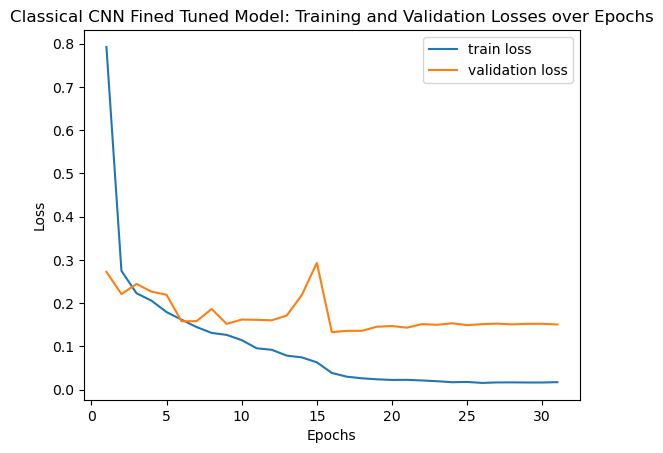

Best model's validation loss (0.13305390068431439) achieved at epoch 16
Total epochs (31)


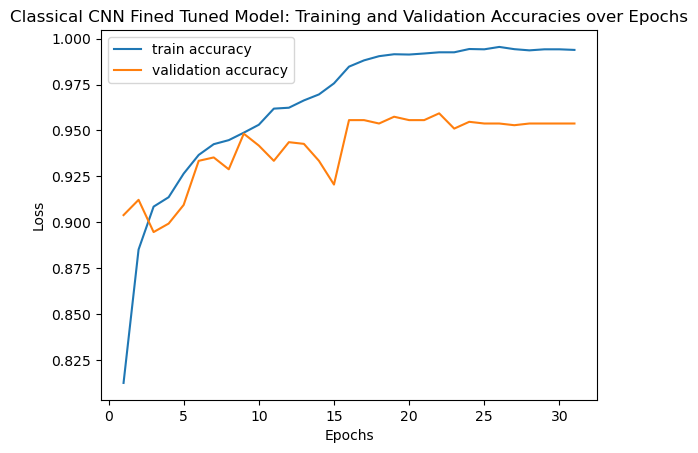

Best model's validation accuracy: 95.563771%
Best model's training accuracy: 98.477695%


In [76]:
plotting.plot_orchestrator_training_summary(best_param_orchestrator, "Classical CNN Fined Tuned Model")

In [77]:
best_param_results = best_param_orchestrator.test(test_loader, best_param_orchestrator.th.best_model_weights)

Test Loss: 0.0727 | Test Acc: 98.1516%


              precision    recall  f1-score   support

     Snoring       0.97      0.99      0.98       539
   InfantCry       0.99      0.97      0.98       543

    accuracy                           0.98      1082
   macro avg       0.98      0.98      0.98      1082
weighted avg       0.98      0.98      0.98      1082



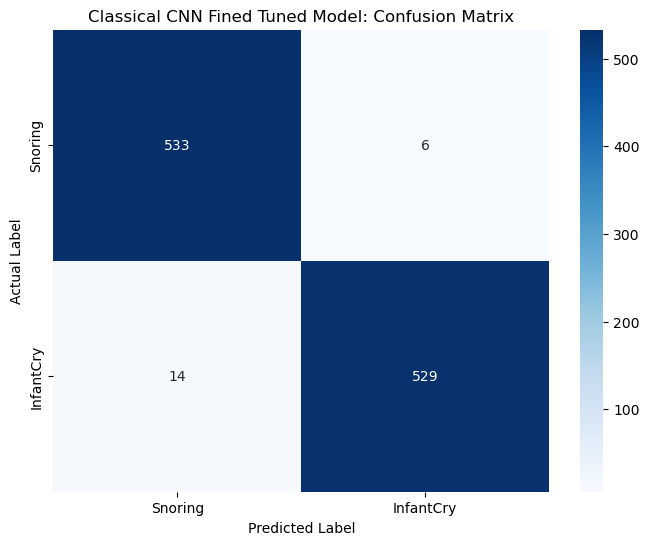

Test Loss: 0.0727 | Test Acc: 98.1516%


In [78]:
plotting.plot_test_results(best_param_results, "Classical CNN Fined Tuned Model")